### Problem Definition:

# **Description of Columns:**

***customerID:*** Categorical feature representing the unique identifier for each customer.

***gender:*** Categorical feature indicating the gender of the customer (Male or Female).

***SeniorCitizen:*** Binary/Numeric feature indicating whether the customer is a senior citizen or not (1 for Yes, 0 for No).

***Partner:*** Categorical feature indicating whether the customer has a partner (Yes, No).

***Dependents:*** Categorical feature indicating whether the customer has dependents (Yes, No).

***tenure:*** Numeric feature representing the number of months the customer has stayed with the company.

***PhoneService:*** Categorical feature indicating whether the customer has a phone service (Yes, No).

***MultipleLines:*** Categorical feature indicating whether the customer has multiple phone lines (Yes, No, No phone service).

***InternetService:*** Categorical feature representing the customer's internet service provider type (DSL, Fiber optic, No).

***OnlineSecurity:*** Categorical feature indicating whether the customer has an online security add-on (Yes, No, No internet service).

***OnlineBackup:*** Categorical feature indicating whether the customer has an online backup add-on (Yes, No, No internet service).

***DeviceProtection:*** Categorical feature indicating whether the customer has a device protection plan (Yes, No, No internet service).

***TechSupport:*** Categorical feature indicating whether the customer has premium tech support (Yes, No, No internet service).

***StreamingTV: ***Categorical feature indicating whether the customer uses the internet service to stream TV (Yes, No, No internet service).

***StreamingMovies:*** Categorical feature indicating whether the customer uses the internet service to stream movies (Yes, No, No internet service).

***Contract:*** Categorical feature indicating the contract term of the customer (Month-to-month, One year, Two year).

***PaperlessBilling: ***Categorical feature indicating whether the customer has opted for paperless billing (Yes, No).

***PaymentMethod:*** Categorical feature indicating the customer's payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic)).

***MonthlyCharges:*** Numeric feature representing the specific amount charged to the customer on a monthly basis.

***TotalCharges:*** Numeric feature representing the total cumulative amount charged to the customer over their entire tenure.

***Churn (Target):*** Binary feature indicating whether the customer churned/left the company within the last month (Yes, No).

# Import Libraries

In [103]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.svm import SVC,LinearSVC
from tensorflow.keras.models import Sequential
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression,LogisticRegression
from tensorflow.keras.layers import Dense,Dropout, Conv2D, MaxPooling2D, Flatten, Dense
from sklearn.metrics import mean_squared_error,accuracy_score,f1_score,precision_score,recall_score,confusion_matrix,classification_report,roc_curve,auc
%matplotlib inline
import warnings
warnings.filterwarnings("ignore")


#### Data Loading and Exploration

In [104]:
df=pd.read_csv('churn_Data.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [105]:
df.tail()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes
7042,3186-AJIEK,Male,0,No,No,66,Yes,No,Fiber optic,Yes,...,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.5,No


In [106]:
df.shape

(7043, 21)

In [107]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [108]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [109]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
5306,5940-NFXKV,Male,0,Yes,Yes,19,Yes,Yes,Fiber optic,No,...,No,No,No,Yes,Month-to-month,Yes,Electronic check,83.65,1465.75,Yes
5373,4043-MKDTV,Male,0,Yes,No,71,Yes,No,Fiber optic,No,...,Yes,Yes,Yes,Yes,Two year,Yes,Electronic check,105.25,7291.75,No
2231,2482-CZGBB,Male,0,No,No,10,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.00,740,Yes
5588,1660-HSOOQ,Male,0,No,No,1,Yes,No,DSL,No,...,Yes,No,No,No,Month-to-month,Yes,Mailed check,49.65,49.65,Yes
16,8191-XWSZG,Female,0,No,No,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,No,Mailed check,20.65,1022.95,No


#### Missing Values

In [110]:
null_counts = df.isnull().sum()
print(null_counts)

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


we see the is no missing values

# Exploratory Data Analysis (EDA)

In [111]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


people have loans counts

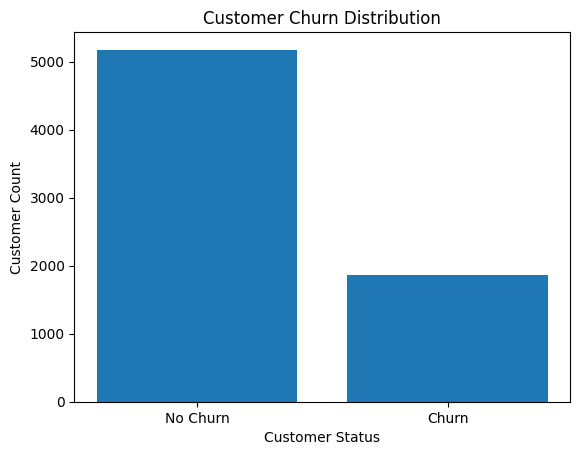

In [112]:
# Count churn values
counts = df["Churn"].value_counts()
counts

# Create bar chart
plt.bar(['No Churn', 'Churn'], counts)

# Set labels and title
plt.xlabel("Customer Status")
plt.ylabel("Customer Count")
plt.title("Customer Churn Distribution")

# Show plot
plt.show()

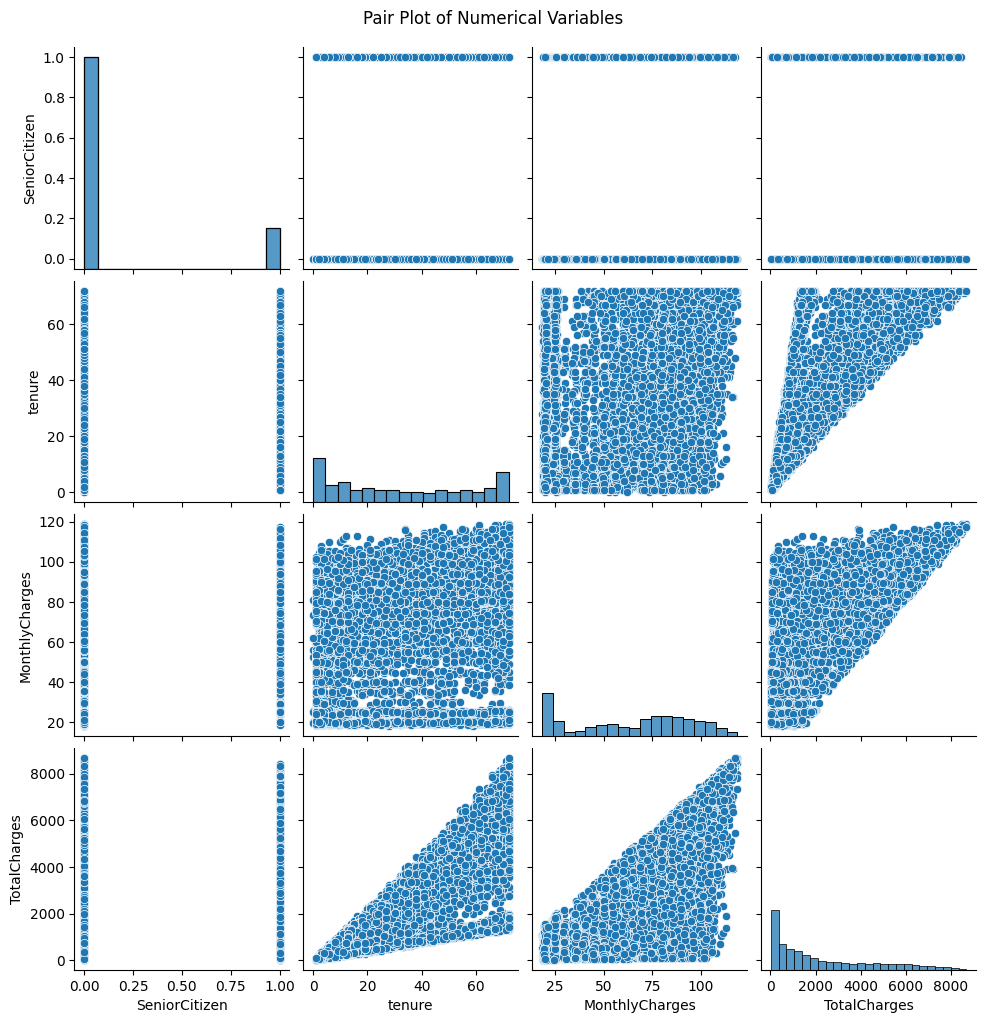

In [113]:
# Convert 'TotalCharges' to numeric so it gets included in the pairplot
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Create pairplot excluding object (string) columns
sns.pairplot(df.select_dtypes(exclude="object"))

# Set title (suptitle centers it above the entire grid)
plt.suptitle('Pair Plot of Numerical Variables', y=1.02)

# Show plot
plt.show()

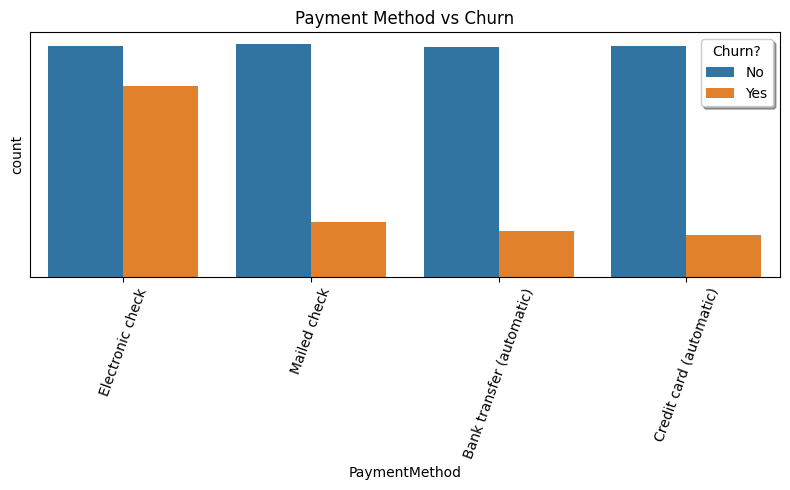

In [114]:

# Create figure
plt.figure(figsize=(8, 5))
plt.title('Payment Method vs Churn')

# Create countplot
g = sns.countplot(x='PaymentMethod', hue='Churn', data=df)

# Formatting
plt.xticks(rotation=70)
plt.yticks([])
plt.legend(title='Churn?', ncol=1, fancybox=True, shadow=True)

# Adjust layout to prevent rotated labels from being cut off
plt.tight_layout()

# Show plot
plt.show()

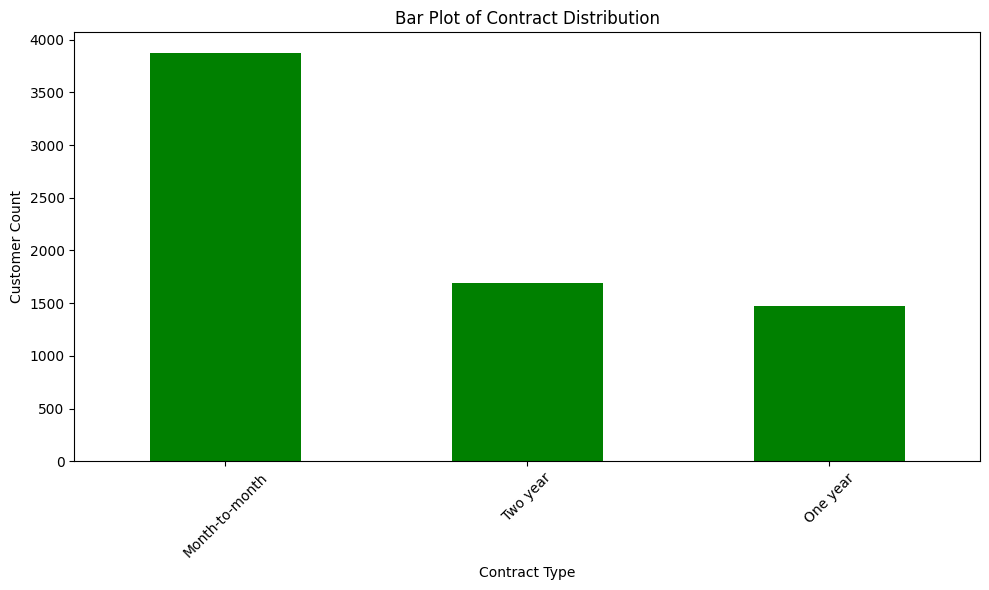

In [115]:
# Create figure
plt.figure(figsize=(10, 6))

# Get value counts for Contract column
contract_counts = df['Contract'].value_counts()

# Plot using pandas built-in plotting
contract_counts.plot(kind='bar', color='green')

# Set labels and title
plt.xlabel('Contract Type')
plt.ylabel('Customer Count')
plt.title('Bar Plot of Contract Distribution')

# Set x-ticks and rotate
plt.xticks(range(len(contract_counts)), contract_counts.index, rotation=45)

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

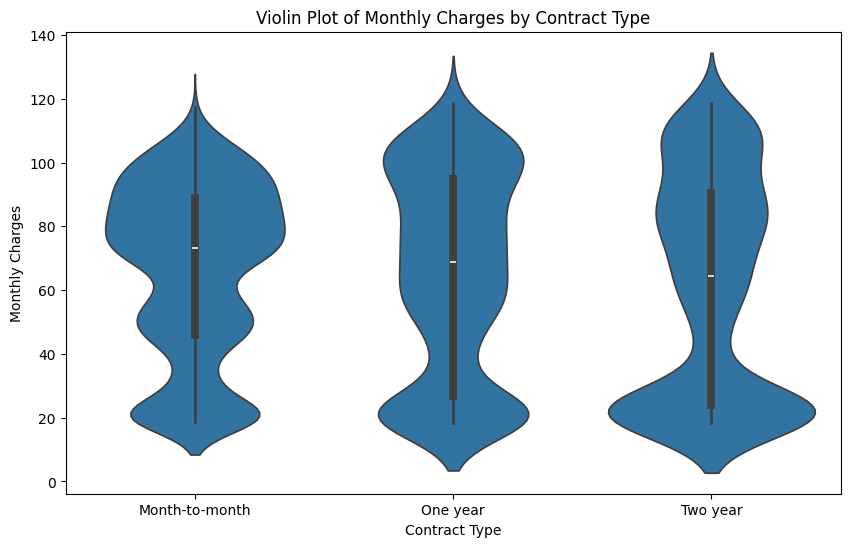

In [116]:
# Create figure
plt.figure(figsize=(10, 6))

# Create violin plot
sns.violinplot(data=df, x='Contract', y='MonthlyCharges')

# Set labels and title
plt.xlabel('Contract Type')
plt.ylabel('Monthly Charges')
plt.title('Violin Plot of Monthly Charges by Contract Type')

# Show plot
plt.show()

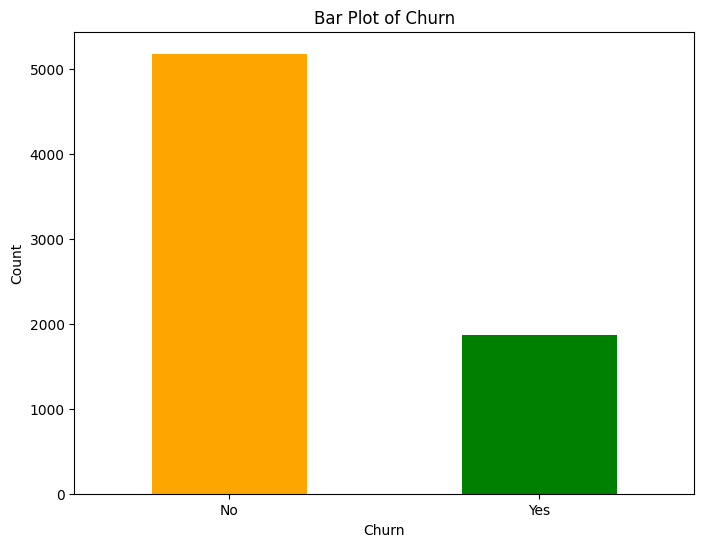

In [117]:
# Create figure
plt.figure(figsize=(8, 6))

# Plot the value counts for Churn with custom colors
df['Churn'].value_counts().plot(kind='bar', color=['orange', 'green'])

# Set labels and title
plt.xlabel('Churn')
plt.ylabel('Count')
plt.title('Bar Plot of Churn')

# Keep x-ticks horizontal
plt.xticks(rotation=0)

# Show plot
plt.show()

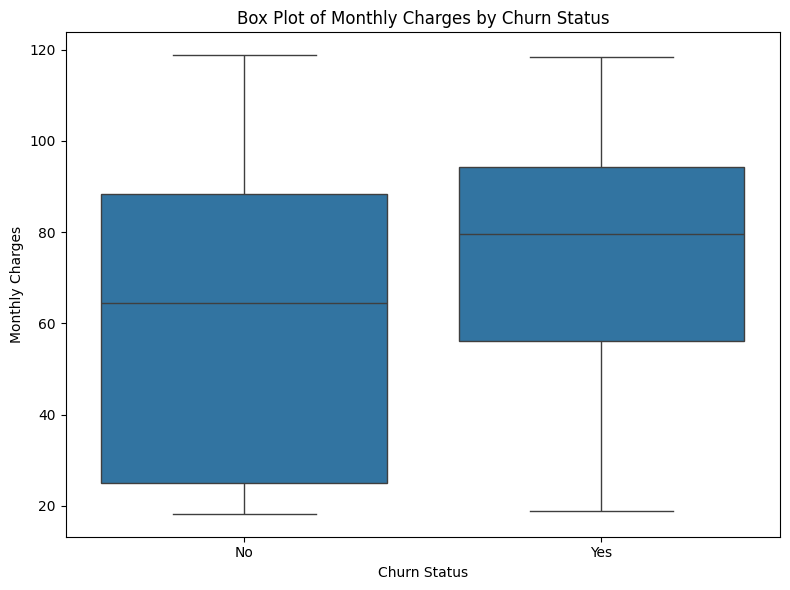

In [118]:
# Create figure
plt.figure(figsize=(8, 6))

# Create box plot
sns.boxplot(data=df, x='Churn', y='MonthlyCharges')

# Set labels and title
plt.xlabel('Churn Status')
plt.ylabel('Monthly Charges')
plt.title('Box Plot of Monthly Charges by Churn Status')

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

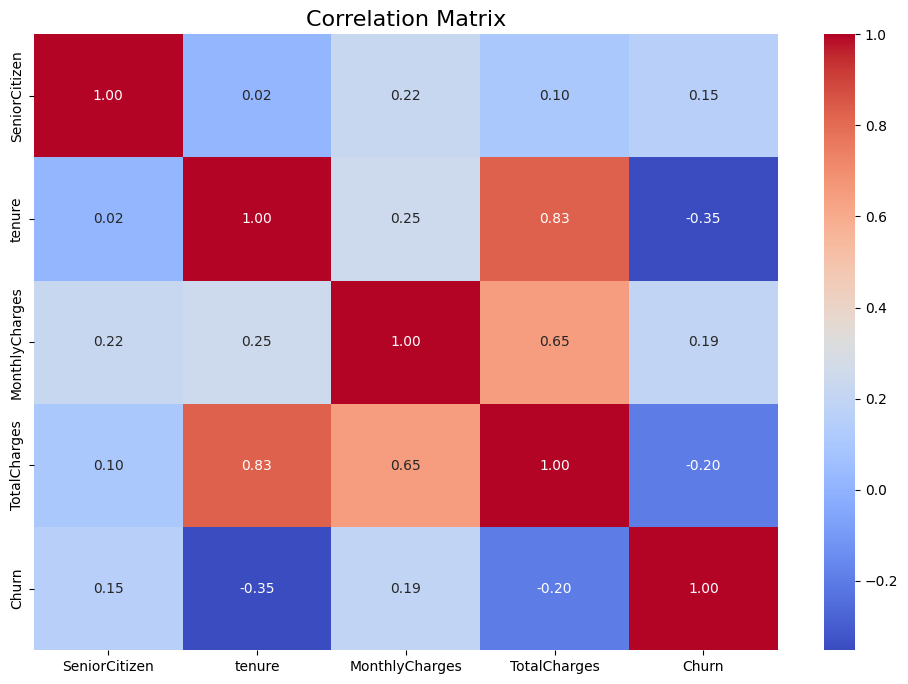

In [119]:
# Create a copy of the dataframe
df2 = df.copy()

# Convert TotalCharges to numeric so it is included in the correlation
df2['TotalCharges'] = pd.to_numeric(df2['TotalCharges'], errors='coerce')

# Label encode the target variable 'Churn' (No = 0, Yes = 1)
df2['Churn'] = LabelEncoder().fit_transform(df2['Churn'])

# Set up the matplotlib figure
fig = plt.figure(figsize=(12, 8))

# Select only the numeric columns
numeric_df = df2.select_dtypes(exclude="object")

# Calculate the correlation matrix
corr = numeric_df.corr()

# Plot the heatmap (annot=True displays the correlation values)
sns.heatmap(corr, cbar=True, cmap='coolwarm', annot=True, fmt=".2f")
plt.title("Correlation Matrix", fontsize=16)

# Show plot
plt.show()

# prepare data for modeling

In [120]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Separate categorical and numerical columns

In [121]:
# fix TotalCharges so it is correctly recognized as a numerical column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# select the categorical and numerical columns
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(exclude=['object']).columns

# Print them out to verify!
print("Categorical Columns:\n", list(categorical_columns))
print("\nNumerical Columns:\n", list(numerical_columns))

Categorical Columns:
 ['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Numerical Columns:
 ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']


In [122]:
df[numerical_columns].head(5)

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
0,0,1,29.85,29.85
1,0,34,56.95,1889.50
2,0,2,53.85,108.15
3,0,45,42.30,1840.75
4,0,2,70.70,151.65


In [123]:
df[categorical_columns].head(5)

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Churn
0,7590-VHVEG,Female,Yes,No,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,No
1,5575-GNVDE,Male,No,No,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,No
2,3668-QPYBK,Male,No,No,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,Yes
3,7795-CFOCW,Male,No,No,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),No
4,9237-HQITU,Female,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,Yes


## convert categorical columns to numerical

Apply label encoding to categorical columns

In [124]:
label_encoder = LabelEncoder()
for column in categorical_columns:
    df[column] = label_encoder.fit_transform(df[column])

Apply scaling to numerical columns

In [125]:
scaler = StandardScaler()
df[numerical_columns] = scaler.fit_transform(df[numerical_columns])
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,5375,0,-0.439916,1,0,-1.277445,0,1,0,0,...,0,0,0,0,0,1,2,-1.160323,-0.994194,0
1,3962,1,-0.439916,0,0,0.066327,1,0,0,2,...,2,0,0,0,1,0,3,-0.259629,-0.173740,0
2,2564,1,-0.439916,0,0,-1.236724,1,0,0,2,...,0,0,0,0,0,1,3,-0.362660,-0.959649,1
3,5535,1,-0.439916,0,0,0.514251,0,1,0,2,...,2,2,0,0,1,0,0,-0.746535,-0.195248,0
4,6511,0,-0.439916,0,0,-1.236724,1,0,1,0,...,0,0,0,0,0,1,2,0.197365,-0.940457,1


# Data spliting

Split features (data) and target variable

In [126]:
# Create the feature matrix 'X' by dropping the target column
X = df.drop(columns=['Churn'])

# Create the target vector 'y'
y = df['Churn']

In [127]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [128]:
# split the data (assuming X and y are already defined from the previous step)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Print the shapes using your exact formatting
print('train features shape: ', X_train.shape)
print('train target   shape: ', y_train.shape)
print('__________\n')
print('test  features shape: ', X_test.shape)
print('test  target   shape: ', y_test.shape)

train features shape:  (5634, 20)
train target   shape:  (5634,)
__________

test  features shape:  (1409, 20)
test  target   shape:  (1409,)


# Modeling

## LinearRegression

### training

In [129]:
# 1. Handle missing values and drop non-predictive ID column
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Drop customerID if it's still in the dataframe
if 'customerID' in df.columns:
    df_model = df.drop(columns=['customerID'])
else:
    df_model = df.copy()

# 2. Separate Features (X) and Target (y) FIRST
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']

# 3. Convert categorical text features into numerical columns
X_encoded = pd.get_dummies(X, drop_first=True)

# 4. Convert the target 'y' to 1s and 0s (Checks if it's text first to prevent errors!)
if y.dtype == 'object':
    y_encoded = y.map({'No': 0, 'Yes': 1})
else:
    y_encoded = y

# 5. Split the data
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

# 6. Initialize and fit Logistic Regression
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)

# 7. Check how well it learned!
print("Training accuracy:", LR.score(X_train, y_train))
print("Testing accuracy:", LR.score(X_test, y_test))

Training accuracy: 0.8003194888178914
Testing accuracy: 0.8176011355571328


### Evaluation

In [130]:
y_pred=LR.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [131]:
y_test

,Churn
185,1
2715,0
3825,0
1807,1
132,0
...,...
6366,0
315,0
2439,0
5002,0


In [132]:
threshold = 0.5
y_pred = np.where(y_pred >= threshold, 1, 0)
print(classification_report(y_test,y_pred,target_names=['not deposit','deposit']))

              precision    recall  f1-score   support

 not deposit       0.86      0.90      0.88      1036
     deposit       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



In [133]:
LR.coef_

array([[-0.05024361,  0.06759275,  0.06989789, -0.18248738, -1.30757244,
        -1.00397931,  0.0735729 ,  0.22768871, -0.29314596, -0.15374095,
        -0.08172204, -0.25648118, -0.01280783,  0.0374794 , -0.72544285,
         0.3593306 ,  0.05926886,  0.66609403,  0.58775041]])

In [134]:
LR.intercept_

array([-0.19123826])

save the results

In [135]:
results = pd.DataFrame(columns=['Model Name','Accuracy','Precision Score','Recall Score','F1-Score','roc_auc'])

### Confusion matrix

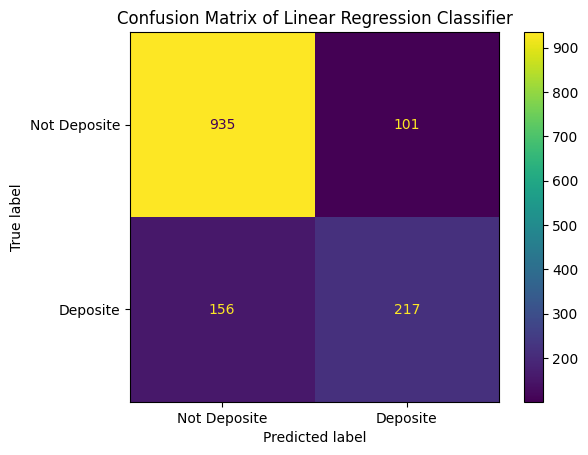

In [136]:
cm_matrix = confusion_matrix(y_test,y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm_matrix, display_labels = ['Not Deposite','Deposite'])
cm_display.plot()
plt.title("Confusion Matrix of Linear Regression Classifier")
plt.show()

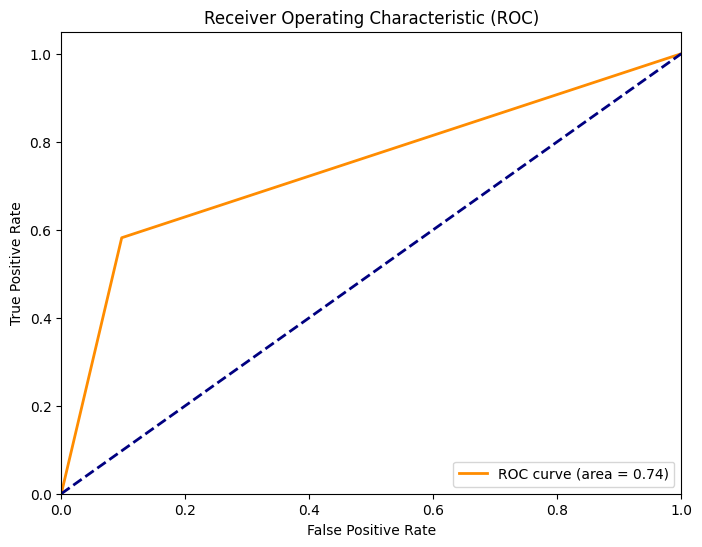

In [137]:
# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [138]:
model_result = ['Linear Regression',accuracy_score(y_test,y_pred),
              precision_score(y_test,y_pred), recall_score(y_test,y_pred),
              f1_score(y_test,y_pred),roc_auc]
results.loc[len(results)]=model_result
results

,Model Name,Accuracy,Precision Score,Recall Score,F1-Score,roc_auc
0,Linear Regression,0.817601,0.68239,0.581769,0.628075,0.74214


## Random forest classifier

### model training

In [139]:
RF=RandomForestClassifier(n_estimators=10,criterion='entropy')
RF.fit(X_train,y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10)

### Evaluation

In [140]:
y_pred=RF.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [141]:
print(classification_report(y_test,y_pred,target_names=['not deposit','deposit']))

              precision    recall  f1-score   support

 not deposit       0.82      0.91      0.86      1036
     deposit       0.63      0.45      0.52       373

    accuracy                           0.78      1409
   macro avg       0.73      0.68      0.69      1409
weighted avg       0.77      0.78      0.77      1409



### the Confusion matrix

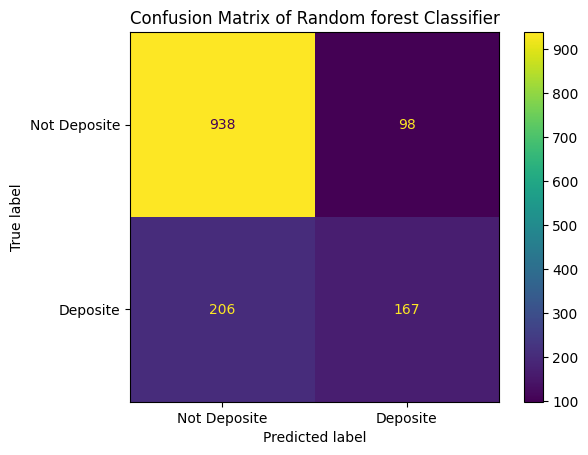

In [142]:

cm_matrix = confusion_matrix(y_test,y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm_matrix, display_labels = ['Not Deposite','Deposite'])
cm_display.plot()
plt.title("Confusion Matrix of Random forest Classifier")
plt.show()

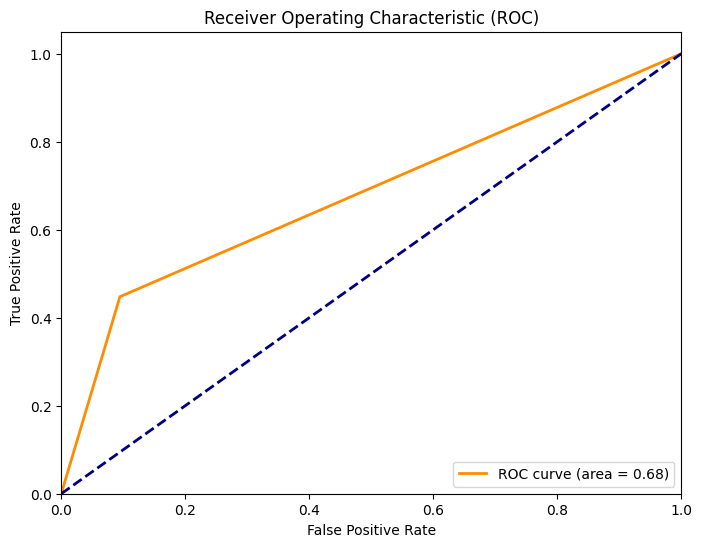

In [143]:
# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

### save reults

In [144]:
model_result = ['Random Forest',accuracy_score(y_test,y_pred),
              precision_score(y_test,y_pred), recall_score(y_test,y_pred),
              f1_score(y_test,y_pred),roc_auc]
results.loc[len(results)]=model_result
results

,Model Name,Accuracy,Precision Score,Recall Score,F1-Score,roc_auc
0,Linear Regression,0.817601,0.682390,0.581769,0.628075,0.742140
1,Random Forest,0.784244,0.630189,0.447721,0.523511,0.676563


## Logistic Regression

### model training

In [145]:
Logistic_regression = LogisticRegression(penalty='l2', dual=False, C=0.9, fit_intercept=True
                        , random_state = 41, max_iter=1000)
Logistic_regression.fit(X_train, y_train)

LogisticRegression(C=0.9, max_iter=1000, random_state=41)

### model evaluation

In [146]:
y_pred=Logistic_regression.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 1])

In [147]:
print(classification_report(y_test,y_pred,target_names=['not deposit','deposit']))

              precision    recall  f1-score   support

 not deposit       0.86      0.90      0.88      1036
     deposit       0.68      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.77      0.74      0.75      1409
weighted avg       0.81      0.82      0.81      1409



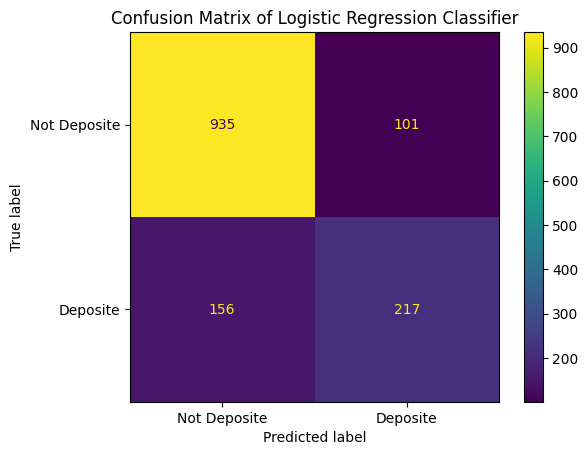

In [148]:

cm_matrix = confusion_matrix(y_test,y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm_matrix, display_labels = ['Not Deposite','Deposite'])
cm_display.plot()
plt.title("Confusion Matrix of Logistic Regression Classifier")
plt.show()

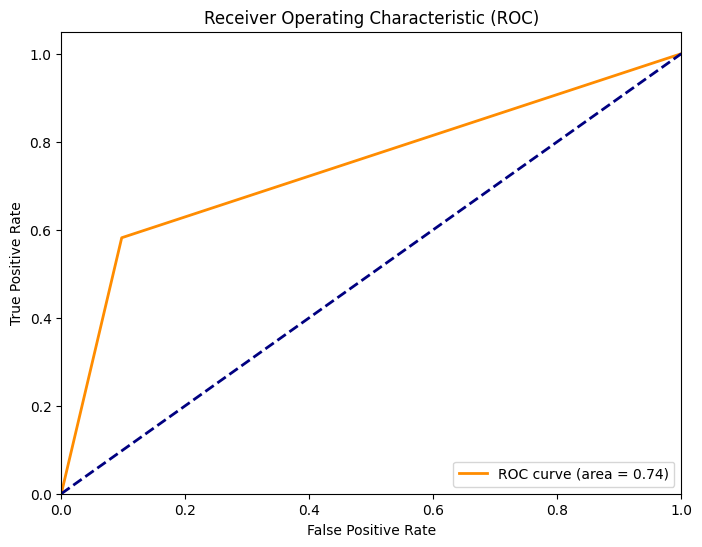

In [149]:
# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

save results

In [150]:
model_result = ['Logistic Regression',accuracy_score(y_test,y_pred),
              precision_score(y_test,y_pred), recall_score(y_test,y_pred),
              f1_score(y_test,y_pred),roc_auc]
results.loc[len(results)]=model_result
results

,Model Name,Accuracy,Precision Score,Recall Score,F1-Score,roc_auc
0,Linear Regression,0.817601,0.682390,0.581769,0.628075,0.742140
1,Random Forest,0.784244,0.630189,0.447721,0.523511,0.676563
2,Logistic Regression,0.817601,0.682390,0.581769,0.628075,0.742140


## Linear Support-Vector Classifier

### mosel training

In [151]:
LSVC = LinearSVC(penalty='l2',dual=False, C=.9)
LSVC.fit(X_train,y_train)

LinearSVC(C=0.9, dual=False)

### Model Evaluation

In [152]:
y_pred=LSVC.predict(X_test)
y_pred

array([1, 0, 0, ..., 0, 0, 0])

In [153]:
print(classification_report(y_test,y_pred,target_names=['not deposit','deposit']))

              precision    recall  f1-score   support

 not deposit       0.86      0.91      0.88      1036
     deposit       0.70      0.58      0.63       373

    accuracy                           0.82      1409
   macro avg       0.78      0.74      0.76      1409
weighted avg       0.82      0.82      0.82      1409



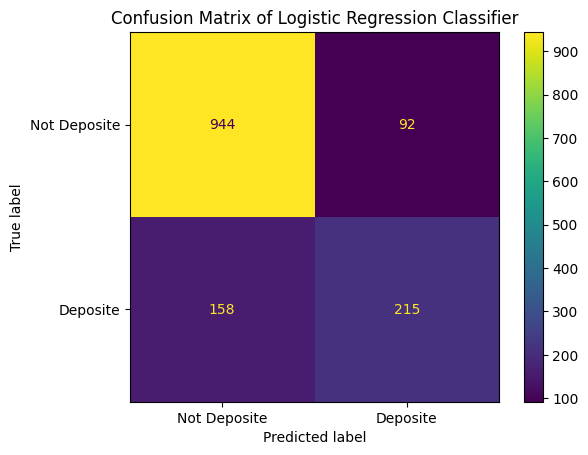

In [154]:

cm_matrix = confusion_matrix(y_test,y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm_matrix, display_labels = ['Not Deposite','Deposite'])
cm_display.plot()
plt.title("Confusion Matrix of Logistic Regression Classifier")
plt.show()

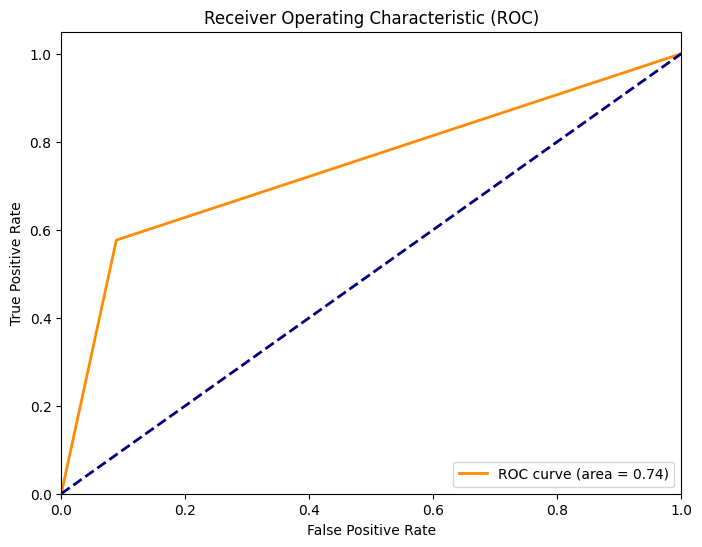

In [155]:
# Compute ROC curve and ROC area for each class
fpr, tpr, _ = roc_curve(y_test, y_pred)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [156]:
model_result = ['Linear SVC',accuracy_score(y_test,y_pred),
              precision_score(y_test,y_pred), recall_score(y_test,y_pred),
              f1_score(y_test,y_pred),roc_auc]
results.loc[len(results)]=model_result
results

,Model Name,Accuracy,Precision Score,Recall Score,F1-Score,roc_auc
0,Linear Regression,0.817601,0.682390,0.581769,0.628075,0.742140
1,Random Forest,0.784244,0.630189,0.447721,0.523511,0.676563
2,Logistic Regression,0.817601,0.682390,0.581769,0.628075,0.742140
3,Linear SVC,0.822569,0.700326,0.576408,0.632353,0.743802


## CNN

### convert data to images
cnn mainly work with images, so we convert our numerical data image shape

In [157]:
#Normalize Data
X_normalized = (df - df.min()) / (df.max() - df.min())

X_array = X_normalized.values

N_samples, N_features = X_array.shape
height = 1
width = N_features
channels = 1
X_reshaped = X_array.reshape(N_samples, height, width, channels)


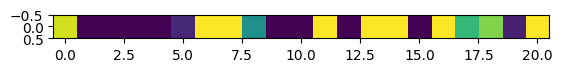

In [158]:
img=X_reshaped[5]
plt.imshow(img)
plt.show()

### split data


In [159]:
X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y, test_size=0.2, random_state=42)
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=0.15, random_state=42)

In [160]:
print('train features shape: ',X_train.shape)
print('train target   shape: ',y_train.shape)
print('__________\n')
print('valid  features shape: ',X_valid.shape)
print('valid  target   shape: ',y_valid.shape)
print('__________\n')
print('test  features shape: ',X_test.shape)
print('test  target   shape: ',y_test.shape)

train features shape:  (4788, 1, 21, 1)
train target   shape:  (4788,)
__________

valid  features shape:  (846, 1, 21, 1)
valid  target   shape:  (846,)
__________

test  features shape:  (1409, 1, 21, 1)
test  target   shape:  (1409,)


In [161]:
model = Sequential([
    Conv2D(2, (3, 3), activation='relu', input_shape=(height, width, channels), padding='same'),
    MaxPooling2D((1, 2)),
    Flatten(),
    Dense(6, activation='relu'),
    Dropout(.1),
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 1, 21, 2)       │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 1, 10, 2)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 20)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           126 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │             7 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 153 (612.00 B)

 Trainable params: 153 (612.00 B)

 Non-trainable params: 0 (0.00 B)

In [162]:
# Train Model
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_valid,y_valid))

Epoch 1/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.6316 - loss: 0.6554 - val_accuracy: 0.7281 - val_loss: 0.5690
Epoch 2/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7414 - loss: 0.5313 - val_accuracy: 0.7376 - val_loss: 0.4918
Epoch 3/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.8033 - loss: 0.4462 - val_accuracy: 0.8652 - val_loss: 0.3840
Epoch 4/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8761 - loss: 0.3424 - val_accuracy: 0.9149 - val_loss: 0.2808
Epoch 5/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9246 - loss: 0.2458 - val_accuracy: 0.9598 - val_loss: 0.1914
Epoch 6/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9547 - loss: 0.1776 - val_accuracy: 0.9681 - val_loss: 0.1353
Epoch 7/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9683 - loss: 0.1315 - val_accuracy: 0.9811 - val_loss: 0.0970
Epoch 8/10
150/150 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9762 - loss: 0.0981 - val_accuracy: 0.

### Evaluate Model

In [163]:

test_loss, test_acc = model.evaluate(X_test, y_test)
print('Test Accuracy:', test_acc)


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9943 - loss: 0.0381
Test Accuracy: 0.9943222403526306


In [164]:
y_pred=model.predict(X_test)
print(y_pred.shape)
y_pred[:5]

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
(1409, 1)


array([[0.99877584],
       [0.02247722],
       [0.01422723],
       [0.99691075],
       [0.02401624]], dtype=float32)

In [165]:
threshold = 0.5
y_pred = np.where(y_pred >= threshold, 1, 0)
print(classification_report(y_test,y_pred,target_names=['not deposit','deposit']))

              precision    recall  f1-score   support

 not deposit       0.99      1.00      1.00      1036
     deposit       1.00      0.98      0.99       373

    accuracy                           0.99      1409
   macro avg       1.00      0.99      0.99      1409
weighted avg       0.99      0.99      0.99      1409



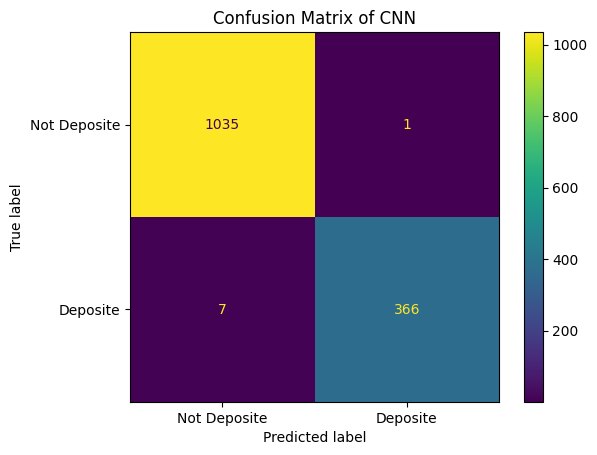

In [166]:

cm_matrix = confusion_matrix(y_test,y_pred)
cm_display = ConfusionMatrixDisplay(confusion_matrix = cm_matrix, display_labels = ['Not Deposite','Deposite'])
cm_display.plot()
plt.title("Confusion Matrix of CNN")
plt.show()

##

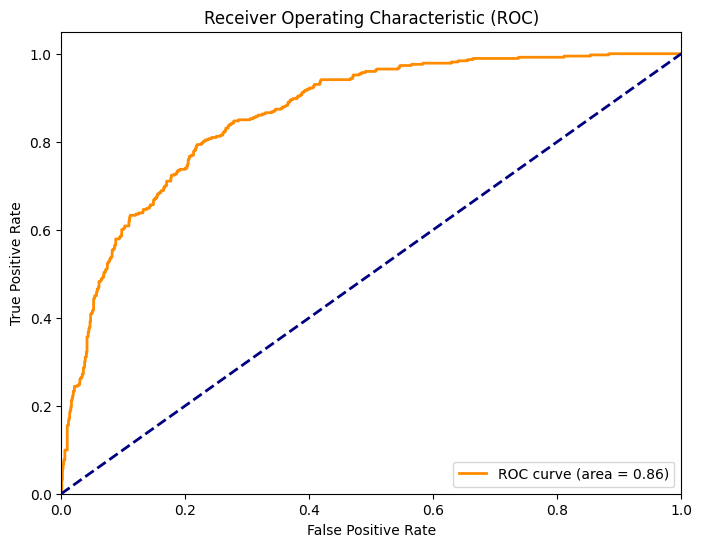

In [167]:
from sklearn.metrics import roc_curve, auc

# PREPARE THE DATA
df = pd.read_csv('churn_Data.csv')
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(0)

# Drop customerID safely
if 'customerID' in df.columns:
    df_model = df.drop(columns=['customerID'])
else:
    df_model = df.copy()

# Separate and Encode
X = df_model.drop(columns=['Churn'])
y = df_model['Churn']
X_encoded = pd.get_dummies(X, drop_first=True)
y_encoded = y.map({'No': 0, 'Yes': 1}) if y.dtype == 'object' else y

# SPLIT AND TRAIN
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y_encoded, test_size=0.2, random_state=42)

LR = LogisticRegression(max_iter=1000)
LR.fit(X_train, y_train)

# EVALUATE AND PLOT ROC
# Get prediction probabilities for Churn = 1 (Yes)
y_pred_prob = LR.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
roc_auc = auc(fpr, tpr)

# Plotting
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.show()

In [168]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Generate the standard predictions (0s and 1s) from our model
y_pred = LR.predict(X_test)

# Initialize the 'results' DataFrame if it doesn't exist yet
if 'results' not in locals():
    results = pd.DataFrame(columns=['Model Name', 'Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC AUC'])

# Create the result list for Logistic Regression
model_result = [
    'Logistic Regression',
    accuracy_score(y_test, y_pred),
    precision_score(y_test, y_pred),
    recall_score(y_test, y_pred),
    f1_score(y_test, y_pred),
    roc_auc  # This variable carries over from your ROC curve block!
]

# Drop the row if 'Logistic Regression' is already in there (prevents duplicates)
results = results.drop(results[results['Model Name'] == 'Logistic Regression'].index, errors='ignore')

# Append the new results to the bottom of the dataframe
results.loc[len(results)] = model_result

# Display the results dataframe
results

,Model Name,Accuracy,Precision Score,Recall Score,F1-Score,roc_auc
0,Linear Regression,0.817601,0.682390,0.581769,0.628075,0.742140
1,Random Forest,0.784244,0.630189,0.447721,0.523511,0.676563
3,Logistic Regression,0.821859,0.687117,0.600536,0.640916,0.862493


In [169]:
model.save('cnn_model.keras')

# Evaluation and comaprison

In [170]:
results

,Model Name,Accuracy,Precision Score,Recall Score,F1-Score,roc_auc
0,Linear Regression,0.817601,0.682390,0.581769,0.628075,0.742140
1,Random Forest,0.784244,0.630189,0.447721,0.523511,0.676563
3,Logistic Regression,0.821859,0.687117,0.600536,0.640916,0.862493


### Accuracy Comparison

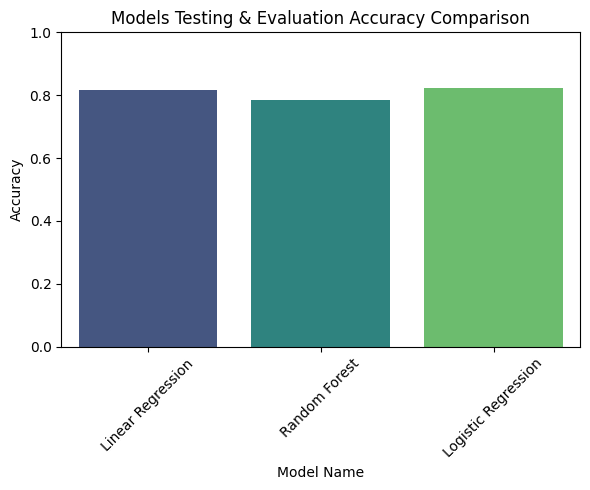

In [171]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create the figure
plt.figure(figsize=(6, 5))

# Create the barplot using the 'results' dataframe
sns.barplot(x="Model Name", y="Accuracy", data=results, palette="viridis")

# Rotate x-labels 45 degrees for better readability
plt.xticks(rotation=45)

# Force the y-axis to represent 0% to 100%
plt.ylim([0, 1.0])

# Add title and adjust layout
plt.title('Models Testing & Evaluation Accuracy Comparison')
plt.tight_layout()

# Show the plot
plt.show()

In [172]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from tensorflow.keras.models import load_model

# 1. Load the trained CNN model
loaded_model = load_model('cnn_model.keras')

# 2. Load the correctly structured dummy dataset (21 columns)
new_data_df = pd.read_csv('load_data.csv')

# 3. Preprocess TotalCharges (convert to numeric and fill blanks)
new_data_df['TotalCharges'] = pd.to_numeric(new_data_df['TotalCharges'], errors='coerce').fillna(0)

# 4. Prepare Features: Drop ONLY the target 'Churn'
if 'Churn' in new_data_df.columns:
    X_new = new_data_df.drop(columns=['Churn'])
else:
    X_new = new_data_df.copy()

# 5. Preprocessing (Label Encoding and Scaling)
categorical_columns = X_new.select_dtypes(include=['object']).columns
numerical_columns = X_new.select_dtypes(exclude=['object']).columns

# Label encode categorical columns
label_encoder = LabelEncoder()
for column in categorical_columns:
    X_new[column] = label_encoder.fit_transform(X_new[column].astype(str))

# Scale numerical columns
scaler = StandardScaler()
X_new[numerical_columns] = scaler.fit_transform(X_new[numerical_columns])

# 6. Reshape for CNN (Samples, Height=1, Width=20, Channels=1)
new_data_array = X_new.values
N_samples_new, N_features_new = new_data_array.shape

# The model expects width to be 20
new_data_reshaped = new_data_array.reshape(N_samples_new, 1, N_features_new, 1)

# 7. Make predictions
predictions = loaded_model.predict(new_data_reshaped)

# 8. Convert probabilities to binary output (0 or 1)
threshold = 0.5
predicted_classes = np.where(predictions >= threshold, 1, 0)

# 9. Summary Output
churned_count = np.sum(predicted_classes == 1)
retained_count = np.sum(predicted_classes == 0)

print("\n--- Prediction Summary ---")
print(f"Total customers evaluated: {len(predicted_classes)}")
print(f"Predicted to Retain (No Churn): {retained_count}")
print(f"Predicted to Churn (Leave): {churned_count}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step

--- Prediction Summary ---
Total customers evaluated: 1000
Predicted to Retain (No Churn): 981
Predicted to Churn (Leave): 19
